A. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

B. Dataset

In [2]:
df = pd.read_csv('./data/amazon_sales_dataset.csv' )
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


C. Preliminary Data Inspection (Understanding Data Characteristics)

In [ ]:
print('Dataset Info: ')
df.info()

display(df.describe())

print(f"\nDataset structure: {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000



Bentuk dataset: 50000 baris dan 13 kolom.


D. Data Cleaning

In [ ]:
# 1. Check for duplicate data
num_duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {num_duplicates}')

if num_duplicates > 0:
    df = df.drop_duplicates()
    print('Duplicate data has been removed')

# 2. Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# 3. Fix data types
# The 'order_date' column should be converted to datetime type
df['order_date'] = pd.to_datetime(df['order_date'])

print("\nData types after correction:")
print(df.dtypes)

Jumlah baris duplikat: 0

Jumlah Missing Values per kolom:
order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

Tipe data setelah diperbaiki:
order_id                     int64
order_date          datetime64[ns]
product_id                   int64
product_category            object
price                      float64
discount_percent             int64
quantity_sold                int64
customer_region             object
payment_method              object
rating                     float64
review_count                 int64
discounted_price           float64
total_revenue              float64
dtype: object


E. Feature Engineering

In [ ]:
# Feature engineering: extract temporal features from 'order_date'
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['day_name'] = df['order_date'].dt.day_name()

# Feature engineering: calculate discount amount
df['discount_amount'] = df['price'] - df['discounted_price']

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,year,month,day_name,discount_amount
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,2022,4,Wednesday,12.87
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,2023,3,Sunday,60.52
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,2022,9,Wednesday,99.16
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,2022,4,Sunday,55.79
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,2022,3,Sunday,0.00


F. Exploratory Data Analysis (EDA) and Visualization

1. Variable Correlation Analysis

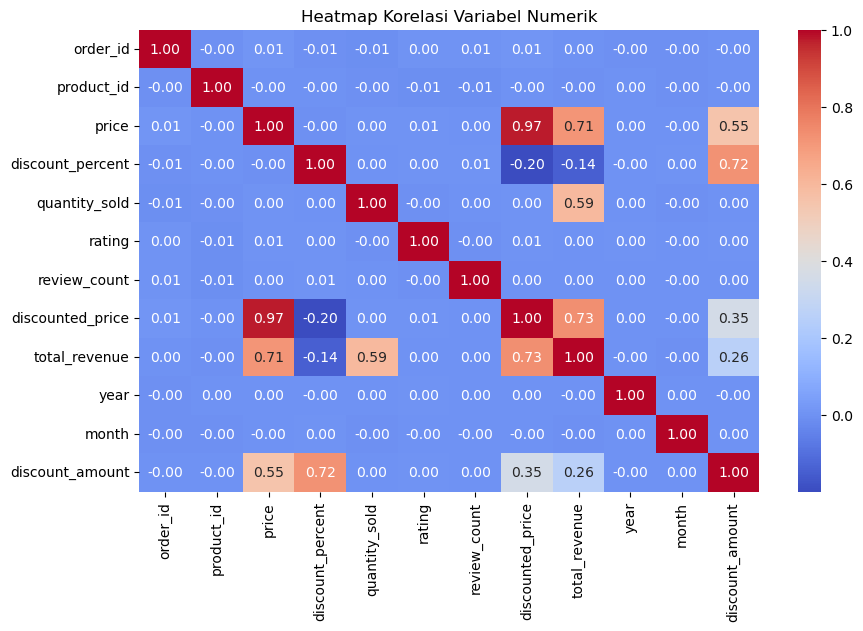

In [ ]:
# Correlation analysis for numerical features
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

2. Product Category with the Highest Revenue

C:\Users\salim\AppData\Local\Temp\ipykernel_30600\644461740.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_revenue, x='total_revenue', y='product_category', palette='viridis')


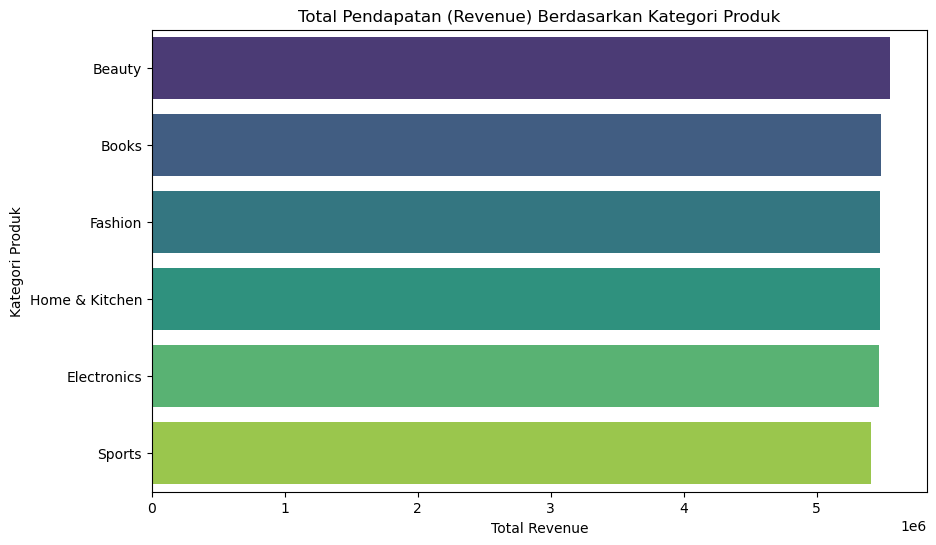

In [ ]:
plt.figure(figsize=(10, 6))

# Aggregate revenue by product category
category_revenue = df.groupby('product_category')['total_revenue'] \
                      .sum() \
                      .sort_values(ascending=False) \
                      .reset_index()

# Visualization: bar chart of revenue by category
sns.barplot(data=category_revenue, x='total_revenue', y='product_category', palette='viridis')

plt.title("Revenue Distribution by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.show()

3. Sales Trend Over Time

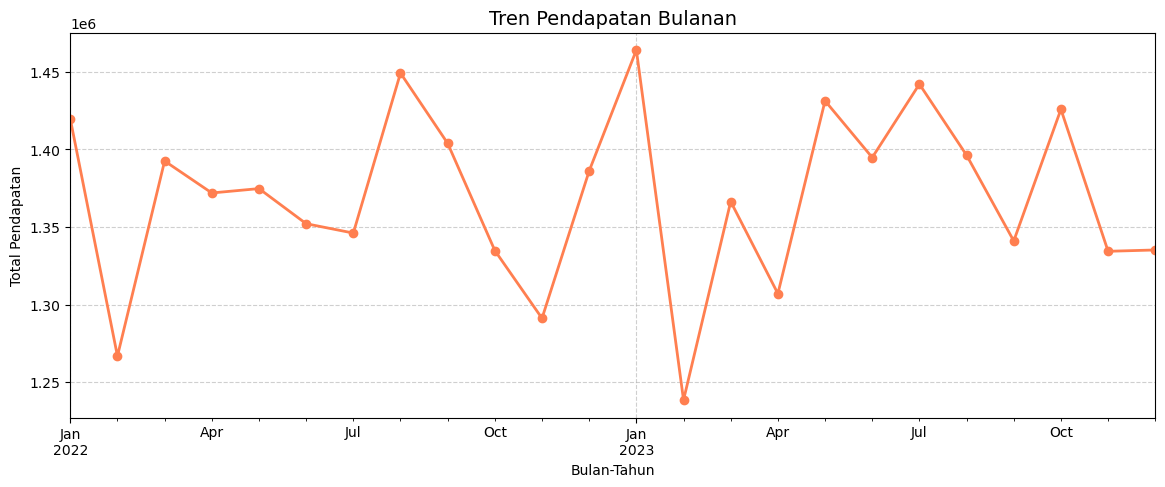

In [ ]:
plt.figure(figsize=(14, 5))

# Time series analysis: monthly revenue trend
monthly_revenue = df.groupby(df['order_date'].dt.to_period('M'))['total_revenue'].sum()

# Visualization: line chart for revenue trend
monthly_revenue.plot(marker='o', linewidth=2)

plt.title("Revenue Trend Over Time", fontsize=14)
plt.xlabel("Month-Year")
plt.ylabel("Revenue")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

4. Customer Shopping Activity by Day of Week

C:\Users\salim\AppData\Local\Temp\ipykernel_30600\2018212683.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='day_name', order=order_days, palette='Blues_d')


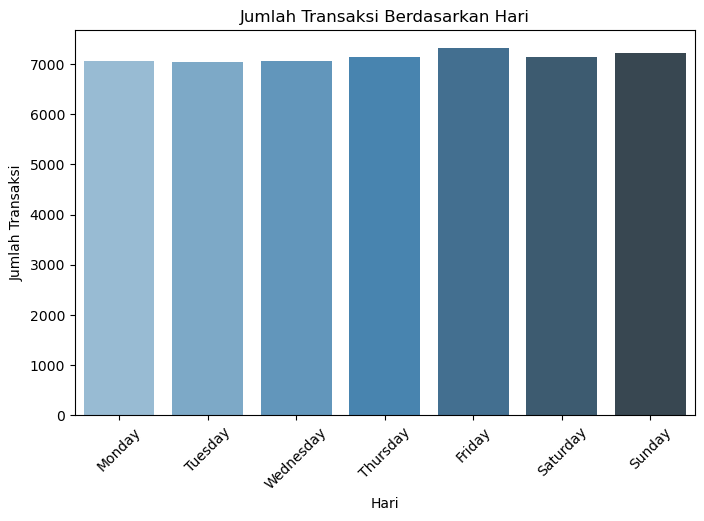

In [ ]:
plt.figure(figsize=(8, 5))

# Analyze transaction frequency by day of the week
order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

sns.countplot(data=df, x='day_name', order=order_days, palette='Blues_d')

plt.title("Transaction Distribution by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)

plt.show()